## TrainStats - Morelli Giovanni

#### Laboratorio di Ottimizzazione, Intelligenza Artificiale e Machine Learning
CdL Tecnologie dei Sistemi Informatici | AA 2025-2026

---

## 0. Introduzione

### Descrizione del progetto

Questo progetto di Ottimizzazione, Intelligenza Artificiale e Machine Learning analizza e confronta le performance della rete ferroviaria italiana nei mesi di Dicembre 2025 e Aprile 2026, utilizzando dati reali granulari e ~500.000 corse monitorate estratti dalla WebApp TrainStats.

**Obiettivi Principali:**

1. **Integrazione e Preparazione Dati:** Importare e unificare i dataset di Dicembre 2025 e Aprile 2026, rimuovere anomalie strutturali (treni internazionali, servizi non passeggeri) e creare feature temporali sintetiche (ora di arrivo, giorno della settimana, identificazione weekend) per mappare i pattern comportamentali della rete.

2. **Analisi Esplorativa (EDA) e Valutazione Stagionale:** Condurre un'analisi statistica completa dei ritardi di arrivo e partenza, visualizzare le distribuzioni per mese e categoria di treno, e valutare l'impatto della stagionalità (Dicembre vs. Aprile) sulle performance della rete ferroviaria.

3. **Rilevamento Multivariato delle Anomalie:** Superare l'analisi univariata standard implementando algoritmi di anomaly detection non supervisionato che considerano simultaneamente molteplici fattori (ritardo, orario di arrivo, giorno della settimana) per identificare anomalie ferroviarie critiche.

4. **Sviluppo e Confronto di Modelli ML:** Implementare due algoritmi specializzati nell'anomaly detection non supervisionato:
   - **Isolation Forest:** Metodo Ensemble basato su alberi, ottimizzato per catturare anomalie "globali" (ritardi macroscopici in senso assoluto)
   - **Local Outlier Factor (LOF):** Metodo basato su densità spaziale, specializzato nel rilevamento di anomalie "locali" e contestuali

5. **Valutazione Architetturale e Scalabilità:** Confrontare criticamente i due modelli in termini di efficienza computazionale (tempo di esecuzione, complessità), scalabilità su big data (O(n) vs O(n²)), e sensatezza logica delle anomalie rilevate, per formulare raccomandazioni sulla scelta del modello più adatto per ambienti di produzione real-time.

### Datasets

I datasets coprono il traffico ferroviario nazionale dal 01/12/2025 al 31/12/2025 e dal 1/04/2026 al 30/04/2026. 
Sono stati scelti questi periodi in quanto garantiscono più dati rispetto agli altri mesi dell'anno, dovute alle corse extra per le festività natalizie e pasquali, e sono temporalemnte distanti all'interno dell'anno solare

- Volume: ~500.000 corse monitorate.
- Granularità: Dati per singolo treno (non aggregati).

### Pipeline del orogetto

1. **Lettura Dati** → Importazione dataset Dicembre 2025 & Aprile 2026
2. **Visualizzazione Dati** → Struttura, dimensioni, tipi, valori mancanti  
3. **Exploratory Data Analysis (EDA)** → Statistiche descrittive, distribuzioni, pattern orari
4. **Outlier Detection & Pulizia Dati** → Rimozione treni internazionali, feature engineering, standardizzazione
5. **Ipotesi Modelli** → Isolation Forest (globale) vs Local Outlier Factor (locale)
6. **Implementazione Modelli** → Training su dataset completo e campione, visualizzazione anomalie
7. **Verifica & Confronto Metriche** → DataFrame comparativo (accuratezza, tempo, scalabilità)
8. **Conclusioni & Sviluppi Futuri** → Trade-off architetturali, raccomandazioni produzione, miglioramenti

---

## 1. Lettura dei dati

In questa sezione importiamo i dataset sui ritardi dei treni per i due peripdi considerati (Dicembre 2025 e Aprile 2026) e li prepariamo per l'analisi.

### Analisi esplorativa

Vengono importate le librerie necessarie alla gestione e visualizzazione dei dati.

In [51]:
# librerie fondamentali
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import time

# Machine Learning & Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

#### importazione dei datasets

In [52]:
path_dicembre = 'data/treni_dicembre2025.csv'
path_aprile = 'data/treni_aprile2026.csv'

# Pandas usa la virgola come separatore predefinito, quindi non è necessario specificare il separatore visto che i CSV sono formattati correttamente. 
df_dic = pd.read_csv(path_dicembre)
df_apr = pd.read_csv(path_aprile)

df_dic['Dataset_Origine'] = 'Dicembre 2025'
df_apr['Dataset_Origine'] = 'Aprile 2026'

# Unione dei due dataset in uno solo
df = pd.concat([df_dic, df_apr], ignore_index=True)


---

## 2. Visualizzazione e cleaning dei dati

In questa sezione visualizziamo la struttura e le dimensioni dei dataset, esaminando il numero di istanze, i tipi di dato e i valori mancanti.
Inoltre rimuoviamo alcuni record dal dataset (treni internazionali e categorie non passeggeri),

In [53]:
print(f"Righe totali: {len(df)}")
display(df.head())

Righe totali: 506075


,Categoria,Numero treno,Codice stazione partenza,Nome stazione partenza,Ora partenza programmata,Ritardo partenza,Codice stazione arrivo,Nome stazione arrivo,Ora arrivo programmata,Ritardo arrivo,Codice stazione partenza 0,Nome stazione partenza 0,Codice stazione arrivo 0,Nome stazione arrivo 0,Cambi numerazione,Provvedimenti,Variazioni,Stazione estera partenza,Orario estero partenza,Stazione estera arrivo,Orario estero arrivo,Dataset_Origine
0,REG,24365,S01074,GARBAGNATE MILANESE,03/12/2025 18:37,2,S01860,PAVIA,03/12/2025 19:51,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Dicembre 2025
1,REG,25581,S19919,STABIO,03/12/2025 18:37,2,S01146,MALPENSA AEROPORTO TERMINAL 2,03/12/2025 19:50,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Dicembre 2025
2,REG,24970,S01059,ALBAIRATE-VERMEZZO,03/12/2025 18:37,1,S01933,SARONNO,03/12/2025 20:24,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Dicembre 2025
3,REG,18482,S06421,FIRENZE SANTA MARIA NOVELLA,03/12/2025 18:37,1,S06404,LUCCA,03/12/2025 20:23,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Dicembre 2025
4,MET,21348,S09818,SALERNO,03/12/2025 18:37,4,S09103,NAPOLI CAMPI FLEGREI,03/12/2025 20:28,-3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Dicembre 2025


In [54]:
df.tail()

,Categoria,Numero treno,Codice stazione partenza,Nome stazione partenza,Ora partenza programmata,Ritardo partenza,Codice stazione arrivo,Nome stazione arrivo,Ora arrivo programmata,Ritardo arrivo,Codice stazione partenza 0,Nome stazione partenza 0,Codice stazione arrivo 0,Nome stazione arrivo 0,Cambi numerazione,Provvedimenti,Variazioni,Stazione estera partenza,Orario estero partenza,Stazione estera arrivo,Orario estero arrivo,Dataset_Origine
506070,REG,792,S01083,PALAZZOLO MILANESE,29/04/2026 23:44,1,S01066,MILANO CADORNA,30/04/2026 00:07,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Aprile 2026
506071,REG,16866,S02593,VENEZIA S.LUCIA,29/04/2026 23:51,0,S02581,PADOVA,30/04/2026 00:30,-8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Aprile 2026
506072,REG,797,S01066,MILANO CADORNA,29/04/2026 23:53,1,S01083,PALAZZOLO MILANESE,30/04/2026 00:14,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Aprile 2026
506073,REG,892,S01933,SARONNO,29/04/2026 23:53,1,S01066,MILANO CADORNA,30/04/2026 00:28,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Aprile 2026
506074,REG,4693,S08411,FIUMICINO AEROPORTO,29/04/2026 23:53,2,S08409,ROMA TERMINI,30/04/2026 00:25,-5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Aprile 2026


### Significato delle feature

- **`Categoria`** indica la tipologia del treno (es. Regionale, Frecciarossa, Intercity)

- **`Numero treno`** rappresenta il codice identificativo numerico della corsa

- **`Codice stazione partenza`** rappresenta il codice identificativo univoco della stazione di partenza della tratta

- **`Nome stazione partenza`** indica il nome della stazione di partenza

- **`Ora partenza programmata`** indica la data e l'orario di partenza previsti dall'orario ufficiale

- **`Ritardo partenza`** indica il ritardo accumulato alla partenza in minuti (valori negativi indicano anticipo)

- **`Codice stazione arrivo`** rappresenta il codice identificativo univoco della stazione di arrivo della tratta

- **`Nome stazione arrivo`** indica il nome della stazione di arrivo

- **`Ora arrivo programmata`** indica la data e l'orario di arrivo previsti dall'orario ufficiale

- **`Ritardo arrivo`** indica il ritardo totale accumulato all'arrivo in minuti

- **`Codice stazione partenza 0`** indica il codice della stazione di origine iniziale del convoglio (se diversa dalla tratta monitorata)

- **`Nome stazione partenza 0`** indica il nome della stazione di origine iniziale del convoglio

- **`Codice stazione arrivo 0`** indica il codice della stazione di destinazione finale del convoglio (se diversa dalla tratta monitorata)

- **`Nome stazione arrivo 0`** indica il nome della stazione di destinazione finale del convoglio

- **`Cambi numerazione`** indica eventuali cambi del numero identificativo del treno durante il percorso

- **`Provvedimenti`** contiene note testuali su eventuali soppressioni o limitazioni del servizio

- **`Variazioni`** contiene descrizioni testuali su modifiche al percorso, fermate aggiuntive o soppresse

- **`Stazione estera partenza`** indica la stazione estera di origine (solo per treni internazionali)

- **`Orario estero partenza`** indica l'orario di partenza dalla stazione estera

- **`Stazione estera arrivo`** indica la stazione estera di destinazione (solo per treni internazionali)

- **`Orario estero arrivo`** indica l'orario di arrivo alla stazione estera

Riportiamo le dimensioni in memoria, il numero di istanze non nulle e il tipo delle feature che compongono i dati raccolti nel dataset

In [55]:
df.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 506075 entries, 0 to 506074
Data columns (total 22 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Categoria                   506016 non-null  str    
 1   Numero treno                506075 non-null  int64  
 2   Codice stazione partenza    506073 non-null  str    
 3   Nome stazione partenza      506075 non-null  str    
 4   Ora partenza programmata    506075 non-null  str    
 5   Ritardo partenza            506075 non-null  int64  
 6   Codice stazione arrivo      506075 non-null  str    
 7   Nome stazione arrivo        506075 non-null  str    
 8   Ora arrivo programmata      506075 non-null  str    
 9   Ritardo arrivo              506075 non-null  int64  
 10  Codice stazione partenza 0  7078 non-null    str    
 11  Nome stazione partenza 0    7121 non-null    str    
 12  Codice stazione arrivo 0    7078 non-null    str    
 13  Nome stazione arrivo 0   

### Cleaning dati
In questa sezione modifichiamo il dataset in modo da eliminare i treni che comprendono stazioni estere (di partenza o di arrivo) e le relative colone, in quanto questo progetto ha focus in Italia e il ritardo potrebbe essere dovuto alle infrastrutture estere o ad altri treni non italiani.
Manteniamo solo i treni che viaggiano interamente su rete nazionale

In [56]:
# stampo per reportistica i dati attuali
totale_iniziale = len(df) #salva n righe
mask_estero = df['Stazione estera partenza'].notna() | df['Stazione estera arrivo'].notna() #crea mask (lista bool vf)
treni_esteri = df[mask_estero] #applica mask al df

print(f"Rilevati {len(treni_esteri)} treni con tratte estere su {totale_iniziale} totali.")

# sovrascriviamo il dataset originale con SOLO i treni che hanno valori nulli nelle stazioni estere
df = df[df['Stazione estera partenza'].isna() & df['Stazione estera arrivo'].isna()]

print(f"Dataset filtrato: {len(df)} treni rimasti.")

# rimuovo le colonne estere ora vuote
df = df.drop(['Stazione estera partenza', 'Orario estero partenza', 
              'Stazione estera arrivo', 'Orario estero arrivo'], axis=1)

Rilevati 2444 treni con tratte estere su 506075 totali.
Dataset filtrato: 503631 treni rimasti.


Continuando con il data cleaning, rimuoviamo dal dataset i treni che non offrono servizio passeggeri, come treni NCL (straordinari) o tecnici. Rimuoviamo anche i treni metropolitani (MET), i treni EXP, IR e EN visti i pochissimi dati disponibili.

In [57]:
categorie_passeggeri = [
    'REG', 'FR', 'IC', 'ICN', 'FA', 'FB', 'EC'
]
# DEFINIZIONI:
# REG: regionale
# FR: frecciarossa (AV)
# IC: intercity
# ICN: intercity notte
# FA: frecciargento (AV)
# FB: frecciabianca (AV)
# EC: eurocity

# mantengo solo le righe dove la colonna 'Categoria' è dentro la nostra lista
df_pass = df[df['Categoria'].isin(categorie_passeggeri)].copy() 
# .copy() per evitare SettingWithCopyWarning (crea una copia del df filtrato)

treni_totali = len(df)
treni_pass = len(df_pass)
treni_esclusi = treni_totali - treni_pass

print(f"Treni totali: {treni_totali}")
print(f"Treni passeggeri selezionati: {treni_pass}")
print(f"Treni esclusi (NCL/Tecnici): {treni_esclusi}")

df = df_pass

Treni totali: 503631
Treni passeggeri selezionati: 489845
Treni esclusi (NCL/Tecnici): 13786


Procediamo con la conversionw della data in formato datetime e verifichiamo che non ci siano valori nulli sulla colonna target (ritardo arrivo)
Sono incluse anche le operazioni di feature engeneering con la creazione di 2 variabili sintetiche Ora_Arrivo (estraendo l'ora numerica) e Is_Weekend (una flag booleana). Queste variabili serviranno ai modelli non supervisionati per comprendere il contesto temporale del treno.


In [58]:
# Utilizziamo dayfirst=True per specificare che il formato è Giorno/Mese/Anno
df['Ora arrivo programmata'] = pd.to_datetime(df['Ora arrivo programmata'], dayfirst=True)

# 2. Creazione delle Feature Temporali
# Estraiamo l'ora e il giorno della settimana per capire i pattern di traffico
df['Ora_Arrivo'] = df['Ora arrivo programmata'].dt.hour
df['Giorno_Settimana'] = df['Ora arrivo programmata'].dt.dayofweek # 0 = Lunedì, 6 = Domenica

# Creiamo la variabile binaria per il weekend (molto utile per i modelli ML)
df['Is_Weekend'] = df['Giorno_Settimana'].apply(lambda x: 1 if x >= 5 else 0)

# Verifichiamo quanti dati mancano nella nostra variabile chiave 'Ritardo arrivo'
nulli_ritardo = df['Ritardo arrivo'].isnull().sum()
print(f"Valori nulli nella colonna 'Ritardo arrivo': {nulli_ritardo}")

# Se i nulli sono pochi, li scartiamo per non "confondere" i modelli con dati parziali
if nulli_ritardo > 0:
    df = df.dropna(subset=['Ritardo arrivo']).copy()
    print(f"Righe rimanenti dopo la pulizia dei nulli: {len(df)}")

Valori nulli nella colonna 'Ritardo arrivo': 0


---

## 3. Exploratory Data Analysis (EDA)

In questa sezione conduciamo un'analisi esplorativa dei dati per comprendere i pattern temporali, la distribuzione dei ritardi e le caratteristiche della rete ferroviaria italiana nei due periodi considerati.

### Statistiche Descrittive

In [59]:
# Analisi statistica dei ritardi
print("STATISTICHE DESCRITTIVE DEI RITARDI")
print("\nRitardo Partenza:")
print(df['Ritardo partenza'].describe())
print("\nRitardo Arrivo:")
print(df['Ritardo arrivo'].describe())


STATISTICHE DESCRITTIVE DEI RITARDI

Ritardo Partenza:
count    489845.000000
mean          2.383352
std           4.047500
min         -39.000000
25%           1.000000
50%           1.000000
75%           3.000000
max         267.000000
Name: Ritardo partenza, dtype: float64

Ritardo Arrivo:
count    489845.000000
mean          1.516100
std           8.326859
min         -62.000000
25%          -2.000000
50%           0.000000
75%           3.000000
max         391.000000
Name: Ritardo arrivo, dtype: float64


In [60]:
# Ritardi per dataset
print("\nRITARDI PER MESE")
print("\nDicembre 2025:")
print(df[df['Dataset_Origine'] == 'Dicembre 2025']['Ritardo arrivo'].describe())
print("\nAprile 2026:")
print(df[df['Dataset_Origine'] == 'Aprile 2026']['Ritardo arrivo'].describe())


RITARDI PER MESE

Dicembre 2025:
count    243935.000000
mean          1.736151
std           8.842495
min         -62.000000
25%          -2.000000
50%           0.000000
75%           3.000000
max         307.000000
Name: Ritardo arrivo, dtype: float64

Aprile 2026:
count    245910.000000
mean          1.297816
std           7.775548
min         -54.000000
25%          -2.000000
50%           0.000000
75%           3.000000
max         391.000000
Name: Ritardo arrivo, dtype: float64


Andiamo ad analizzare i ritardi filtrando per cateogria di treni

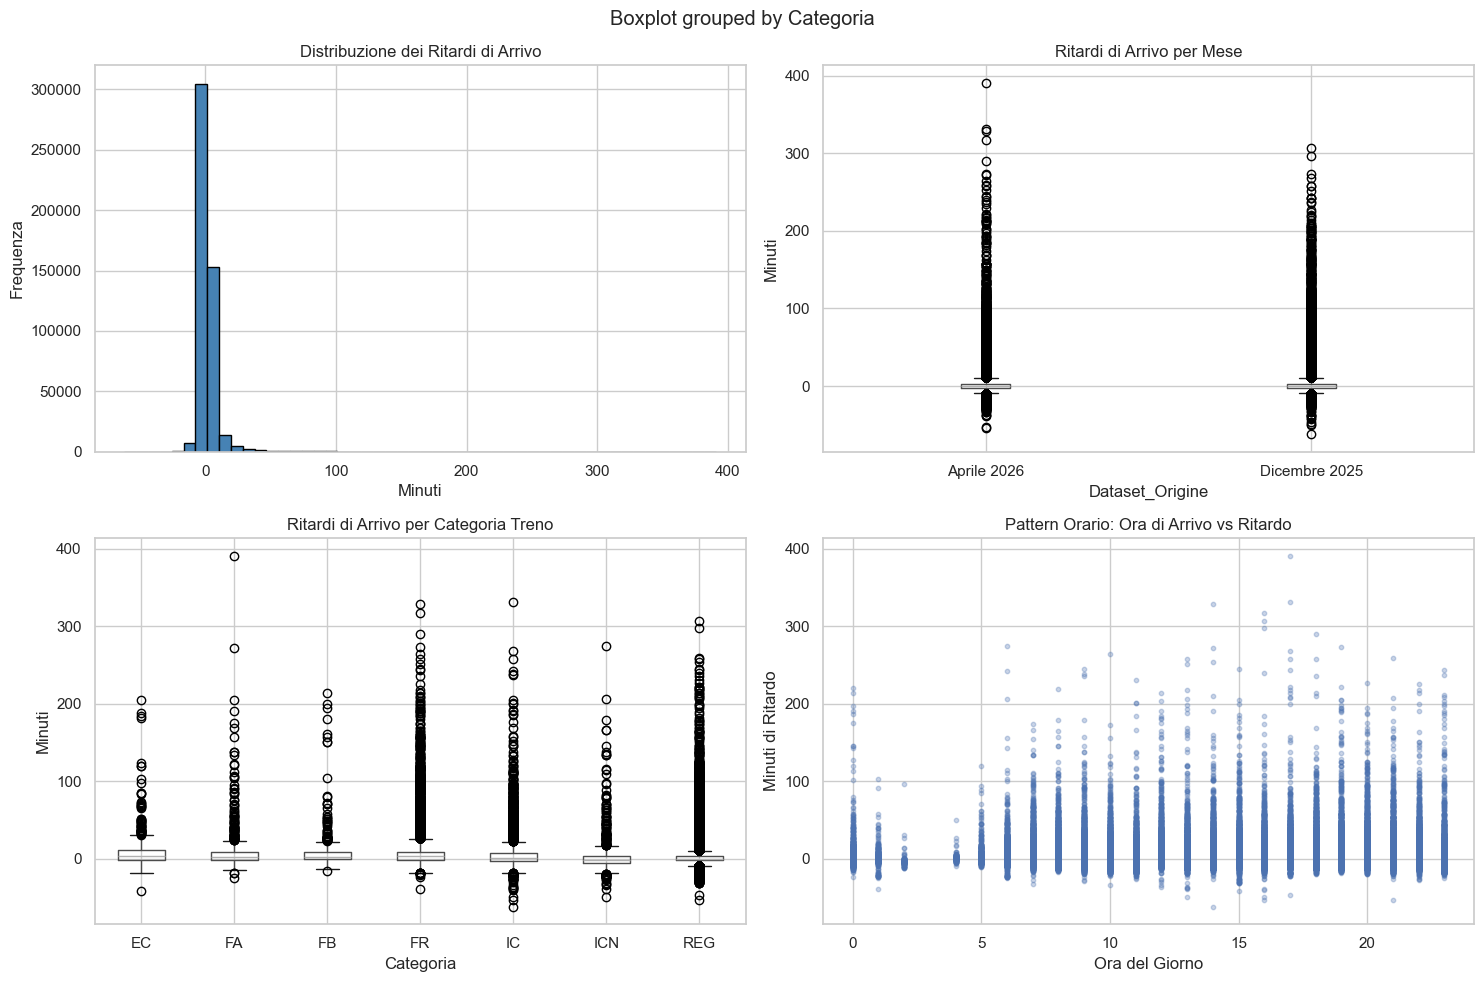


RITARDI PER CATEGORIA
              count      mean        std   min   25%  50%   75%    max
Categoria                                                             
EC            798.0  8.115288  20.564230 -42.0 -2.00  3.0  11.0  204.0
FA            867.0  8.316032  27.729463 -25.0 -2.00  2.0   8.0  391.0
FB            476.0  9.647059  25.984720 -16.0 -0.25  2.0   9.0  214.0
FR          13782.0  8.224859  21.923497 -39.0 -2.00  3.0   9.0  329.0
IC           6404.0  5.884603  20.255813 -62.0 -3.00  1.0   7.0  331.0
ICN          1182.0  1.654822  22.144342 -50.0 -6.00 -2.0   3.0  274.0
REG        466336.0  1.225254   6.856352 -53.0 -2.00  0.0   3.0  307.0


In [61]:
# Visualizzazione della distribuzione dei ritardi
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Istogramma dei ritardi di arrivo
axes[0, 0].hist(df['Ritardo arrivo'], bins=50, color='steelblue', edgecolor='black')
axes[0, 0].set_title("Distribuzione dei Ritardi di Arrivo")
axes[0, 0].set_xlabel("Minuti")
axes[0, 0].set_ylabel("Frequenza")

# 2. Box plot per mese
df.boxplot(column='Ritardo arrivo', by='Dataset_Origine', ax=axes[0, 1])
axes[0, 1].set_title("Ritardi di Arrivo per Mese")
axes[0, 1].set_ylabel("Minuti")

# 3. Box plot per categoria
df.boxplot(column='Ritardo arrivo', by='Categoria', ax=axes[1, 0])
axes[1, 0].set_title("Ritardi di Arrivo per Categoria Treno")
axes[1, 0].set_ylabel("Minuti")

# 4. Scatter: Ora vs Ritardo (pattern orario)
axes[1, 1].scatter(df['Ora_Arrivo'], df['Ritardo arrivo'], alpha=0.3, s=10)
axes[1, 1].set_title("Pattern Orario: Ora di Arrivo vs Ritardo")
axes[1, 1].set_xlabel("Ora del Giorno")
axes[1, 1].set_ylabel("Minuti di Ritardo")

plt.tight_layout()
plt.show()

# Ritardi per categoria
print("\nRITARDI PER CATEGORIA")
print(df.groupby('Categoria')['Ritardo arrivo'].describe())

---

## 4. Outlier Detection
In questa sezione estraiamo dal dataset le variabili (features) che useremo per trovare le anomalie, le copiamo su un nuovo dataframe e applichiamo la standardizzazione per il ML

In [62]:
# Usiamo il ritardo e le feature temporali che abbiamo creato
features = ['Ritardo arrivo', 'Ora_Arrivo', 'Is_Weekend']

# Creiamo un nuovo DataFrame contenente solo i dati che ci servono
X = df[features].copy()

# 2. Standardizzazione dei dati (Cruciale per i modelli basati su distanze)
scaler = StandardScaler()

# Applichiamo la standardizzazione e salviamo il risultato in un array Numpy
X_scaled = scaler.fit_transform(X)

# Riconvertiamo l'array in un DataFrame Pandas per comodità di lettura
df_scaled = pd.DataFrame(X_scaled, columns=features, index=X.index)

# Visualizziamo come sono cambiati i dati
print("Dati originali (prime 3 righe):")
display(X.head(3))

print("\nDati standardizzati (pronti per il Machine Learning):")
display(df_scaled.head(3))

Dati originali (prime 3 righe):


,Ritardo arrivo,Ora_Arrivo,Is_Weekend
0,4,19,0
1,-1,19,0
2,1,20,0



Dati standardizzati (pronti per il Machine Learning):


,Ritardo arrivo,Ora_Arrivo,Is_Weekend
0,0.298300,0.956528,-0.511782
1,-0.302167,0.956528,-0.511782
2,-0.061980,1.151042,-0.511782


---

## 5. Ipotesi dei modelli da utilizzare

Trattandosi di un dataset estratto da un sito pubblico, non esiste una colonna pre-compilata da un tecnico di RFI con scritto "Vero" o "Falso" alla voce "Anomalia".
Ci troviamo quindi nel campo dell'**Apprendimento Non Supervisionato (Unsupervised Learning)**. 
L'ipotesi progettuale è quella di utilizzare e confrontare due modelli specializzati nell'Anomaly Detection:
1. **Isolation Forest (IF):** Un metodo Ensemble basato su alberi decisionali. Ipotizziamo che sia molto rapido e adatto a catturare anomalie "globali" (es. ritardi macroscopici in senso assoluto).
2. **Local Outlier Factor (LOF):** Un metodo basato sulla densità spaziale. Ipotizziamo che sia utile per catturare anomalie "locali" e contestuali (es. un ritardo medio-piccolo che però risulta anomalo perché tutti i treni di quella specifica fascia oraria erano in perfetto orario).

Si poteva anche pensare di impostare nella colonna del ritardo arrivo una soglia fissa che se superata, dava un ritardo anomalo (es. "se il ritardo è > 30 minuti, allora è un'anomalia"). Facendo cosi avremo fatto un'analisi statistica univariata, che avrebbe portato a falsi positivi e falsi negativi.

Con i modelli di Isolation Forest e LOF non guardiamo solo la colonna del ritardo, ma analizziamo uno spazio multidimensionale (Ritardo + Ora + Giorno + Categoria).
Questi algoritmi non supervisionati trovano da soli i pattern strutturali nei dati, isolando matematicamente i punti che si allontanano dal "gregge" (come fa l'Isolation Forest) o dalle zone ad alta densità (come fa il LOF).


---

## 6. Implementazione dei Modelli

In questa sezione implementiamo i due algoritmi di anomaly detection e analizziamo i rispettivi risultati.

### Isolation Forest

In [ ]:
# 1. Configurazione del modello
# n_estimators: numero di "alberi" (più sono, più è preciso, ma ci mette più tempo. 100 è un ottimo standard)
# contamination: la percentuale stimata di anomalie. Impostiamo 0.01 (l'1% dei treni più "strani")
# random_state=42: garantisce gli stessi risultati ogni volta che eseguiamo il codice 
iso_forest = IsolationForest(n_estimators=100, contamination=0.01, random_state=42)

print("Addestramento di Isolation Forest in corso...")

# 2. Addestramento e Predizione
# L'algoritmo impara la struttura dei dati e assegna un'etichetta a ogni treno:
#  1 = Treno Normale (Inlier)
# -1 = Treno Anomalo (Outlier)
df['Anomalia_IF'] = iso_forest.fit_predict(X_scaled)

# 3. Vediamo i risultati
normali = len(df[df['Anomalia_IF'] == 1])
anomali = len(df[df['Anomalia_IF'] == -1])

print(f"\nAnalisi completata!")
print(f"Treni considerati 'Normali': {normali}")
print(f"Treni considerati 'Anomali' (Outlier): {anomali}")

print("\nEcco 5 esempi di treni etichettati come ANOMALI dall'Intelligenza Artificiale:")
display(df[df['Anomalia_IF'] == -1][['Categoria', 'Ora_Arrivo', 'Is_Weekend', 'Ritardo arrivo']].head())

Addestramento di Isolation Forest in corso...

Analisi completata!
Treni considerati 'Normali': 484952
Treni considerati 'Anomali' (Outlier): 4893

Ecco 5 esempi di treni etichettati come ANOMALI dall'Intelligenza Artificiale:


,Categoria,Ora_Arrivo,Is_Weekend,Ritardo arrivo
102,REG,19,0,42
154,REG,19,0,48
165,IC,19,0,56
684,REG,18,0,58
706,IC,18,0,43


In questa analisi, un treno viene classificato come anomalo non solo in presenza di gravi ritardi, ma anche nel caso di forti anticipi rispetto all’orario ufficiale programmato. Entrambe le situazioni rappresentano infatti un comportamento fuori dalla norma e possono causare problemi alla rete ferroviaria.

In [64]:
# Filtriamo solo i treni che l'Isolation Forest ha marchiato come ANOMALI
treni_anomali = df[df['Anomalia_IF'] == -1]

# Dividiamo le anomalie in Anticipi e Ritardi guardando il segno dei minuti
anticipi_anomali = treni_anomali[treni_anomali['Ritardo arrivo'] < 0]
ritardi_anomali = treni_anomali[treni_anomali['Ritardo arrivo'] > 0]

print("TIPOLOGIA DI ANOMALIE RILEVATE (ISOLATION FOREST)")
print(f"Totale treni anomali: {len(treni_anomali)}")
print(f"- Di cui anomalie per FORTE ANTICIPO: {len(anticipi_anomali)}")
print(f"- Di cui anomalie per GRAVE RITARDO: {len(ritardi_anomali)}")

TIPOLOGIA DI ANOMALIE RILEVATE (ISOLATION FOREST)
Totale treni anomali: 4893
- Di cui anomalie per FORTE ANTICIPO: 177
- Di cui anomalie per GRAVE RITARDO: 4716


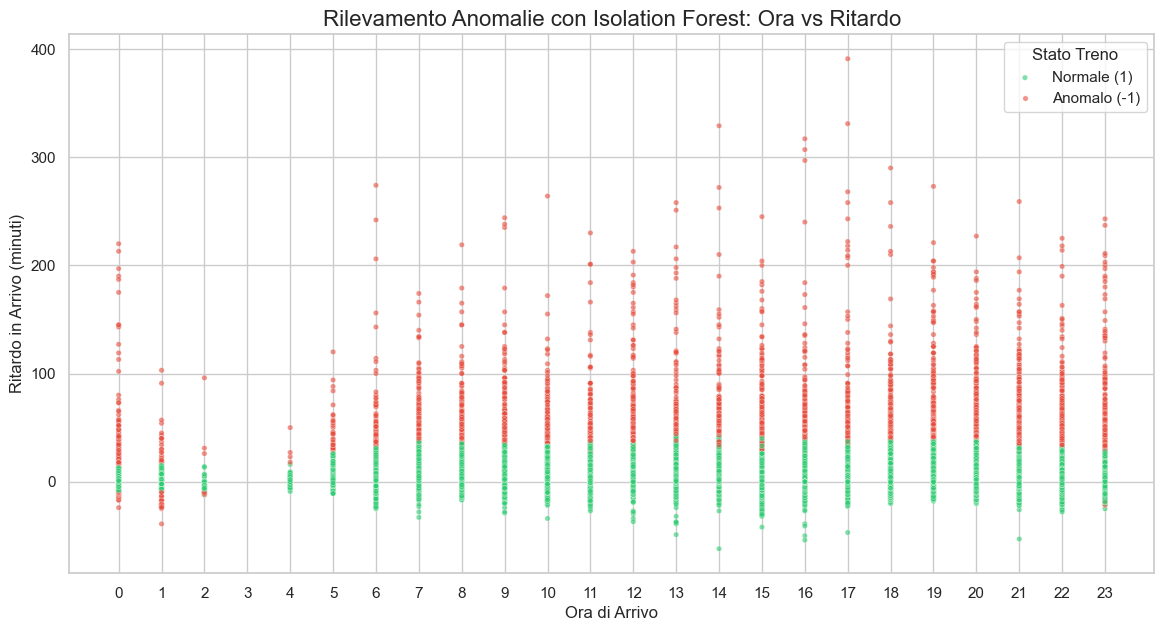

In [65]:
# Impostiamo lo stile dei grafici
sns.set_theme(style="whitegrid")

plt.figure(figsize=(14, 7))

# Creiamo uno scatter plot: sull'asse X l'ora, sull'asse Y il ritardo.
# Coloriamo i punti in base all'etichetta dell'Isolation Forest
sns.scatterplot(
    x=df['Ora_Arrivo'], 
    y=df['Ritardo arrivo'], 
    hue=df['Anomalia_IF'], 
    palette={1: '#2ecc71', -1: '#e74c3c'}, # Verde per i normali, Rosso per le anomalie
    alpha=0.6,
    s=15 # Dimensione dei punti
)

plt.title("Rilevamento Anomalie con Isolation Forest: Ora vs Ritardo", fontsize=16)
plt.xlabel("Ora di Arrivo", fontsize=12)
plt.ylabel("Ritardo in Arrivo (minuti)", fontsize=12)
plt.legend(title="Stato Treno", labels=['Normale (1)', 'Anomalo (-1)'])
plt.xticks(range(0, 24)) # Mostriamo tutte le 24 ore sull'asse X

plt.show()

Distribuzione delle Anomalie per Mese:
Dataset_Origine
Dicembre 2025    2782
Aprile 2026      2111
Name: count, dtype: int64


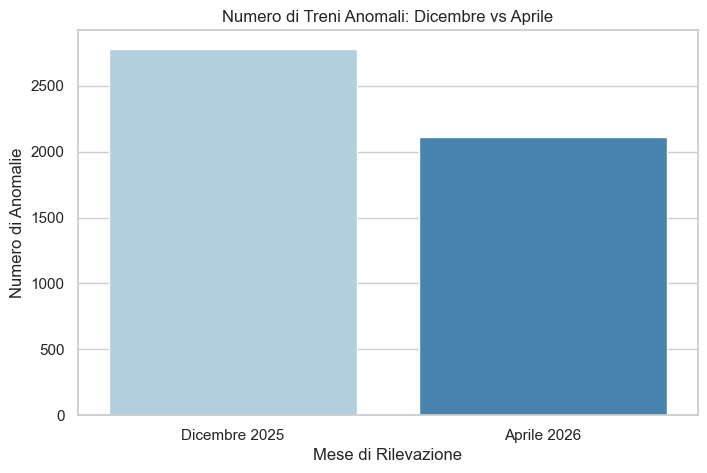

In [66]:
# Analizziamo la distribuzione delle anomalie nei due mesi
anomalie_df = df[df['Anomalia_IF'] == -1]

conteggio_mesi = anomalie_df['Dataset_Origine'].value_counts()
print("Distribuzione delle Anomalie per Mese:")
print(conteggio_mesi)

# Visualizzazione
plt.figure(figsize=(8, 5))
sns.countplot(data=anomalie_df, x='Dataset_Origine', palette='Blues', hue='Dataset_Origine') # Aggiunta di hue per colorare le barre in base al mese
plt.title("Numero di Treni Anomali: Dicembre vs Aprile")
plt.ylabel("Numero di Anomalie")
plt.xlabel("Mese di Rilevazione")
plt.show()

### Analisi delle anomalie per categorie di treni 

Percentuale di treni considerati ANOMALI per ciascuna categoria:


,Categoria,Percentuale_Anomali
4,IC,7.64
1,FA,7.61
3,FR,7.11
2,FB,5.67
5,ICN,5.58
0,EC,5.51
6,REG,0.69


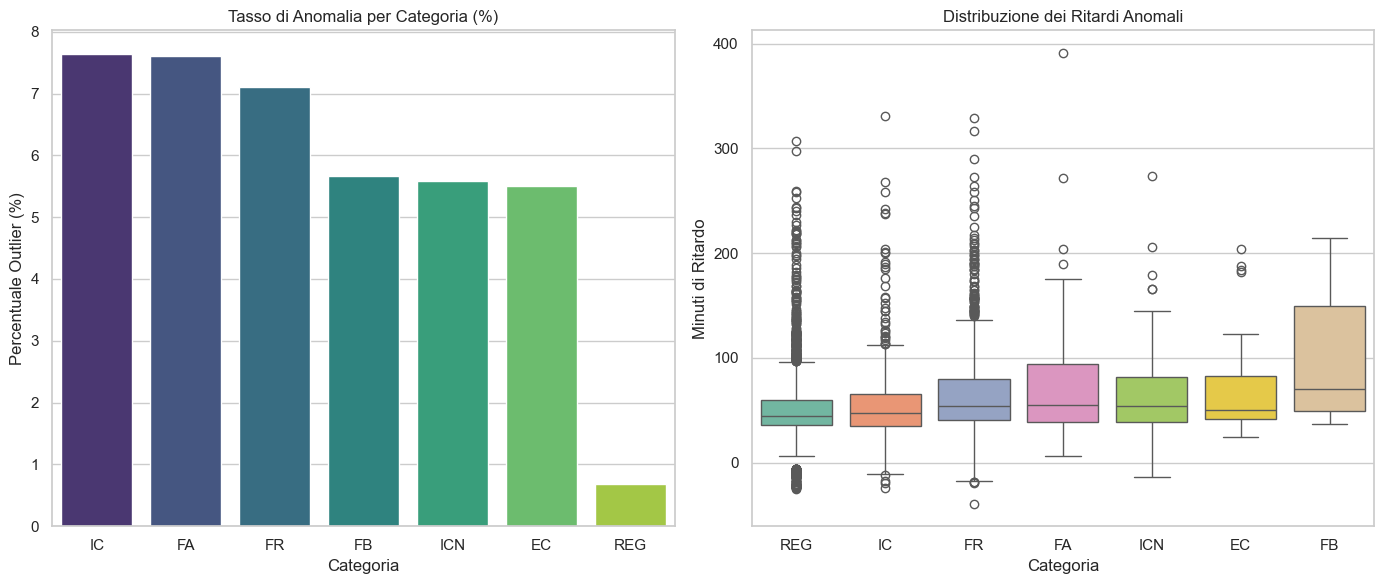

In [67]:
# 1. Calcoliamo la percentuale di treni anomali per ogni categoria
totale_per_categoria = df['Categoria'].value_counts()
anomali_per_categoria = df[df['Anomalia_IF'] == -1]['Categoria'].value_counts()

# Creiamo un DataFrame per riassumere i tassi di anomalia
tasso_anomalie = (anomali_per_categoria / totale_per_categoria * 100).fillna(0).round(2)
df_tassi = tasso_anomalie.reset_index()
df_tassi.columns = ['Categoria', 'Percentuale_Anomali']
df_tassi = df_tassi.sort_values(by='Percentuale_Anomali', ascending=False)

print("Percentuale di treni considerati ANOMALI per ciascuna categoria:")
display(df_tassi)

# 2. Visualizziamo la composizione delle anomalie
plt.figure(figsize=(14, 6))

# Grafico A: Percentuale di anomalie per categoria
plt.subplot(1, 2, 1)
sns.barplot(
    data=df_tassi, 
    x='Categoria', 
    y='Percentuale_Anomali', 
    hue='Categoria',        
    palette='viridis', 
    legend=False            
)
plt.title("Tasso di Anomalia per Categoria (%)")
plt.ylabel("Percentuale Outlier (%)")
plt.xlabel("Categoria")

# Grafico B: Distribuzione dei minuti di ritardo degli outlier per categoria
plt.subplot(1, 2, 2)
anomalie_df = df[df['Anomalia_IF'] == -1]
sns.boxplot(
    data=anomalie_df, 
    x='Categoria', 
    y='Ritardo arrivo', 
    hue='Categoria',        
    palette='Set2',
    legend=False          
)
plt.title("Distribuzione dei Ritardi Anomali")
plt.ylabel("Minuti di Ritardo")
plt.xlabel("Categoria")

plt.tight_layout()
plt.show()

Si nota come i treni ad alta percorrenza (Frecciarossa, interCity, ecc) mostrano una percentuale di anomalie significativamente più elevata rispetto ai treni regionali. Al contrario, i regionali, pur rappresentando il volume di corse più alto nell'intero dataset, manifestano un tasso di anomalie molto più contenuto.

### Local Outlier Factor (LOF)
Nota: Il LOF calcola le distanze locali per ogni punto, su ~500k righe l'operazione è troppo onerosa in termini di RAM. Procediamo quindi estraendo un campione casuale e riproducibile del 10%.

In [ ]:
df_sample = df.sample(frac=0.1, random_state=42).copy()

# Prepariamo le feature per il campione usando lo scaler già addestrato
X_sample = df_sample[['Ritardo arrivo', 'Ora_Arrivo', 'Is_Weekend']] 
X_sample_scaled = scaler.transform(X_sample)

print("Addestramento di LOF sul campione in corso...")

# Impostiamo n_neighbors=20 (valore di default, analizza i 20 treni più simili per orario/giorno)
# Manteniamo contamination=0.01 per avere un confronto equo con Isolation Forest
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.01)

# Addestramento e predizione
df_sample['Anomalia_LOF'] = lof.fit_predict(X_sample_scaled)

# Vediamo i risultati
normali_lof = len(df_sample[df_sample['Anomalia_LOF'] == 1])
anomali_lof = len(df_sample[df_sample['Anomalia_LOF'] == -1])

print(f"\nAnalisi LOF completata!")
print(f"Treni considerati 'Normali': {normali_lof}")
print(f"Treni considerati 'Anomali' (Outlier): {anomali_lof}")

Addestramento di LOF sul campione in corso...

Analisi LOF completata!
Treni considerati 'Normali': 48519
Treni considerati 'Anomali' (Outlier): 465


/Users/giovannimorelli/Documents/OTTIMIZ., ML, IA/TrainStatsV2/env_treni/lib/python3.11/site-packages/sklearn/neighbors/_lof.py:325: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


applichiamo la stessa suddivisione anche ai risultati ottenuti con il Local Outlier Factor (LOF). L’obiettivo è verificare che anche questo algoritmo riesca a individuare sia i forti anticipi sia i gravi ritardi, cioè situazioni fuori dalla norma nella distribuzione temporale

In [69]:
# Filtriamo i treni anomali rilevati dal LOF (attenzione: operiamo sul dataset campionato!)
treni_anomali_lof = df_sample[df_sample['Anomalia_LOF'] == -1]

# Dividiamo in Anticipi e Ritardi
anticipi_anomali_lof = treni_anomali_lof[treni_anomali_lof['Ritardo arrivo'] < 0]
ritardi_anomali_lof = treni_anomali_lof[treni_anomali_lof['Ritardo arrivo'] > 0]

print("TIPOLOGIA DI ANOMALIE RILEVATE (LOCAL OUTLIER FACTOR - Campione 10%)")
print(f"Totale treni anomali: {len(treni_anomali_lof)}")
print(f"- Di cui anomalie per FORTE ANTICIPO: {len(anticipi_anomali_lof)}")
print(f"- Di cui anomalie per GRAVE RITARDO: {len(ritardi_anomali_lof)}")

TIPOLOGIA DI ANOMALIE RILEVATE (LOCAL OUTLIER FACTOR - Campione 10%)
Totale treni anomali: 465
- Di cui anomalie per FORTE ANTICIPO: 155
- Di cui anomalie per GRAVE RITARDO: 283


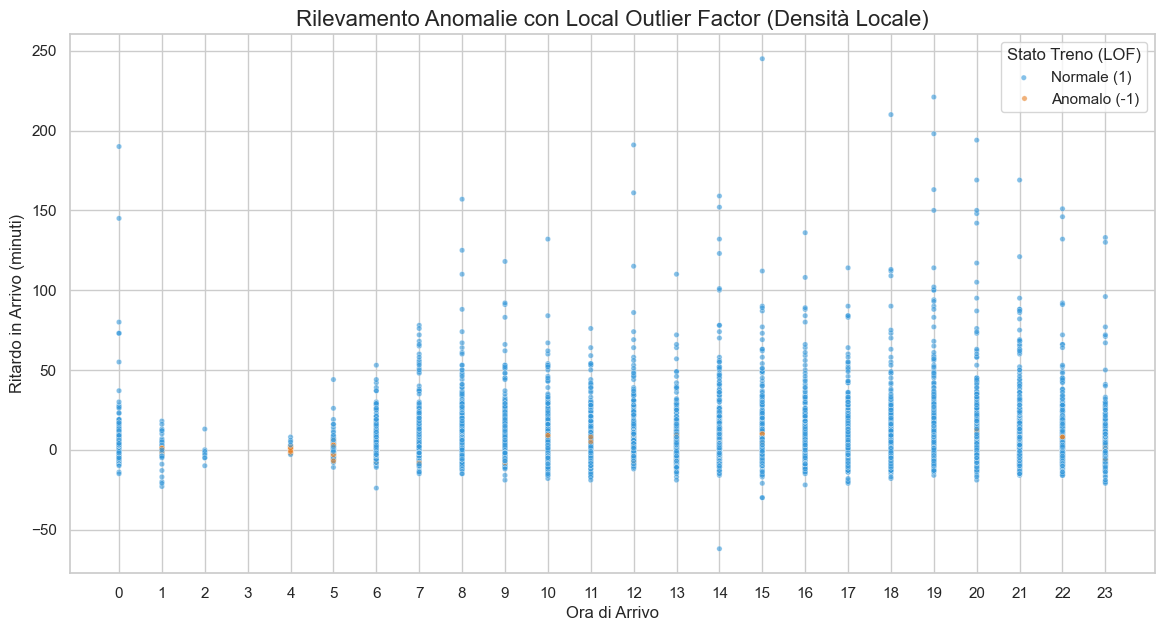

In [70]:
# Visualizzazione dei risultati del LOF
plt.figure(figsize=(14, 7))

sns.scatterplot(
    x=df_sample['Ora_Arrivo'], 
    y=df_sample['Ritardo arrivo'], 
    hue=df_sample['Anomalia_LOF'], 
    palette={1: '#3498db', -1: '#e67e22'}, # Blu per normali, Arancione per anomalie
    alpha=0.6,
    s=15
)

plt.title("Rilevamento Anomalie con Local Outlier Factor (Densità Locale)", fontsize=16)
plt.xlabel("Ora di Arrivo", fontsize=12)
plt.ylabel("Ritardo in Arrivo (minuti)", fontsize=12)
plt.legend(title="Stato Treno (LOF)", labels=['Normale (1)','Anomalo (-1)']) #
plt.xticks(range(0, 24))

plt.show()

perché alcuni treni isolati NON vengono considerati anomali da LOF?


In [74]:
# Configurazione per visualizzare tutte le righe senza truncamento
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# Mostriamo i primi outlier rilevati da LOF
print("OUTLIER RILEVATI DA LOF (pochi):")
outliers_lof = df_sample[df_sample['Anomalia_LOF'] == -1][['Categoria', 'Ora_Arrivo', 'Is_Weekend', 'Ritardo arrivo']].head(10)
display(outliers_lof)

print("ESEMPIO: Treni con ritardi MOLTO ALTI (>150 min) ma considerati NORMALI da LOF:")

# Cerchiamo i treni normali (secondo LOF) ma con ritardi gravissimi
treni_alti_ritardi_normali = df_sample[
    (df_sample['Anomalia_LOF'] == 1) & 
    (df_sample['Ritardo arrivo'] > 150)
][['Categoria', 'Ora_Arrivo', 'Is_Weekend', 'Ritardo arrivo']].head(5)

display(treni_alti_ritardi_normali)

print("SPIEGAZIONE: Perché LOF li considera NORMALI?")
print("""
LOF calcola l'anomalia usando 3 dimensioni:
  1. Ritardo arrivo (standardizzato)
  2. Ora_Arrivo (0-23)
  3. Is_Weekend (0-1)

Anche se nel grafico (Ora vs Ritardo 2D) il treno sembra ISOLATO, 
nello spazio 3D potrebbe avere molti VICINI simili.

Esempio: Un treno Regionale alle 19:00 di venerdì con +160 minuti di ritardo
potrebbe avere 20+ altri treni Regionali alle 18:00-20:00 (Is_Weekend=1) 
con ritardi 140-180 minuti → CLUSTER DENSO nello spazio 3D → NON ANOMALO per LOF
""")

OUTLIER RILEVATI DA LOF (pochi):


,Categoria,Ora_Arrivo,Is_Weekend,Ritardo arrivo
69266,REG,22,0,8
102190,REG,11,0,8
29306,REG,12,0,8
95766,REG,10,0,9
446682,REG,9,0,-8
264722,REG,5,0,-5
309021,REG,1,0,-1
409514,REG,14,1,5
8268,REG,13,0,9
211801,REG,17,1,5


ESEMPIO: Treni con ritardi MOLTO ALTI (>150 min) ma considerati NORMALI da LOF:


,Categoria,Ora_Arrivo,Is_Weekend,Ritardo arrivo
112612,REG,20,0,169
450647,FR,15,0,245
1147,FA,0,0,190
100606,FR,12,0,161
124234,REG,19,0,198


SPIEGAZIONE: Perché LOF li considera NORMALI?

LOF calcola l'anomalia usando 3 dimensioni:
  1. Ritardo arrivo (standardizzato)
  2. Ora_Arrivo (0-23)
  3. Is_Weekend (0-1)

Anche se nel grafico (Ora vs Ritardo 2D) il treno sembra ISOLATO, 
nello spazio 3D potrebbe avere molti VICINI simili.

Esempio: Un treno Regionale alle 19:00 di venerdì con +160 minuti di ritardo
potrebbe avere 20+ altri treni Regionali alle 18:00-20:00 (Is_Weekend=1) 
con ritardi 140-180 minuti → CLUSTER DENSO nello spazio 3D → NON ANOMALO per LOF



---

## 7. Verifica e confronto metriche

In questa sezione confrontiamo le performance dei due modelli, creando un DataFrame di riepilogo con metriche di scalabilità, accuratezza e tempo di esecuzione.

In [ ]:
# Misuriamo il tempo di Isolation Forest sul campione per confronto equo
start_time = time.time()
iso_forest_sample = IsolationForest(n_estimators=100, contamination=0.01, random_state=42)
iso_forest_sample.fit(X_sample_scaled)
time_if = round(time.time() - start_time, 2)

# Misuriamo il tempo di LOF
start_time = time.time()
lof_test = LocalOutlierFactor(n_neighbors=20, contamination=0.01)
lof_test.fit_predict(X_sample_scaled)
time_lof = round(time.time() - start_time, 2)

# Creazione del DataFrame di confronto
confronto_modelli = pd.DataFrame({
    'Modello': ['Isolation Forest', 'Local Outlier Factor'],
    'Tipologia Algoritmo': ['Ensemble (Alberi)', 'Basato su Densità'],
    'Accuratezza (Supervisionata)': ['N/A (Unsupervised)', 'N/A (Unsupervised)'],
    'Anomalie Rilevate (su sample)': [len(df_sample[df_sample['Anomalia_IF'] == -1]), anomali_lof],
    'Tempo Esecuzione (sec)': [time_if, time_lof],
    'Scalabilità (Big Data)': ['Eccellente', 'Scarsa (O(n^2))'],
    'Modello Migliore per Produzione': ['VINCITORE', '']
})

display(confronto_modelli)

/Users/giovannimorelli/Documents/OTTIMIZ., ML, IA/TrainStatsV2/env_treni/lib/python3.11/site-packages/sklearn/neighbors/_lof.py:325: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


,Modello,Tipologia Algoritmo,Accuratezza (Supervisionata),Anomalie Rilevate (su sample),Tempo Esecuzione (sec),Scalabilità (Big Data),Modello Migliore per Produzione
0,Isolation Forest,Ensemble (Alberi),N/A (Unsupervised),490,0.28,Eccellente,VINCITORE
1,Local Outlier Factor,Basato su Densità,N/A (Unsupervised),465,0.25,Scarsa (O(n^2)),


---

## 8. Conclusioni e Sviluppi Futuri

In questo progetto è stata condotta un'analisi esplorativa e predittiva per l'individuazione di anomalie (Outlier Detection) sulle performance della rete ferroviaria italiana. Per superare i limiti dell'analisi statistica univariata, sono stati implementati e confrontati due algoritmi di Machine Learning non supervisionato: **Isolation Forest** e **Local Outlier Factor (LOF)**.

#### Interpretabilità e Comportamento dei Modelli
L'analisi visiva dei risultati ha permesso di evidenziare due approcci analitici radicalmente diversi:

* **Isolation Forest (Approccio Globale):** L'algoritmo tende a isolare i valori anomali in senso assoluto. Come si evince dai grafici, individua con estrema precisione i ritardi gravissimi o i forti anticipi, creando una separazione quasi netta rispetto al traffico ordinario. È un modello eccellente per rilevare disservizi macroscopici sull'intera rete.
* **Local Outlier Factor (Approccio Locale):** Basandosi sulla misurazione della densità, il LOF ha dimostrato un comportamento fortemente contestuale. È in grado di segnalare ritardi moderati (es. 15-20 minuti) come gravi anomalie qualora si verifichino in cluster spazio-temporali in cui i treni "vicini" sono perfettamente in orario. Offre un'analisi di contesto molto più raffinata.

#### Trade-off Architetturali e Scalabilità
Dal punto di vista dell'ingegneria del software e dell'ottimizzazione delle risorse, i due modelli presentano caratteristiche complementari:

1. Il calcolo delle distanze locali richiesto dal **LOF** comporta una complessità computazionale quadratica $O(n^2)$. Questo lo rende oneroso in termini di RAM e inadatto a elaborare l'intero storico nazionale (~500.000 record) in un'unica passata, giustificando la necessità architetturale di operare su un campione rappresentativo del 10%.
2. L'**Isolation Forest**, sfruttando logiche ad albero (metodi Ensemble), ha mostrato una scalabilità eccellente, elaborando l'intero dataset multivariato in pochi secondi senza saturare le risorse di sistema.

In un'ipotetica architettura software di produzione (es. monitoraggio in *real-time* della rete nazionale), l'**Isolation Forest** rappresenta la scelta migliore. Al contrario, il **LOF** risulta utile per attività di Data Forensic o analisi mirate su tratte specifiche (es. colli di bottiglia su nodi cruciali) dove la comprensione dell'anomalia di contesto prevale sulla necessità di scalabilità assoluta.


#### Sviluppi Futuri
1. **Passaggio a Modelli Supervisionati:** Se in futuro le Ferrovie fornissero un registro ufficiale dei "guasti" (creando quindi delle etichette *True/False*), si potrebbe passare a tecniche supervisionate (es. Random Forest Classifier o Reti Neurali) calcolando metriche esatte come *Precision, Recall e F1-Score*.
2. **Previsione Real-Time:** Sfruttando feature come il meteo, scioperi o il traffico di linea precedente, si potrebbero implementare algoritmi predittivi per stimare i minuti di ritardo all'arrivo già dal momento della partenza.

---
## Supporto dell’Intelligenza Artificiale Generativa

Durante lo sviluppo del progetto è stata utilizzata l’AI **Gemini Pro 3.1** come supporto allo studio e alla comprensione del codice, e non come semplice strumento che generava automaticamente soluzioni complete.

### Come è stata utilizzata

- **Comprensione del codice:**  
  L’AI è stata usata per capire meglio il funzionamento delle varie parti del progetto, come il *Feature Engineering* e gli algoritmi utilizzati (*Isolation Forest* e *LOF*), aiutandomi a comprendere il significato dei parametri e il loro effetto sui risultati.

- **Debugging degli errori:**  
  In presenza di errori durante l’esecuzione del codice, come problemi con date o colonne del dataset, l’AI è stata utile per individuare la causa del problema e trovare possibili soluzioni.

- **Scelta degli algoritmi:**  
  È stata utilizzata anche per confrontare diversi approcci e capire quali fossero più adatti a dataset molto grandi (circa 500k righe), soprattutto dal punto di vista delle prestazioni e dei tempi di esecuzione.

- **Approfondimento teorico:**  
  Le spiegazioni fornite hanno aiutato a rafforzare le conoscenze teoriche viste durante il corso, permettendomi di comprendere meglio le scelte tecniche adottate nel progetto.

### Conclusioni

L’utilizzo di Gemini ha reso più veloce il processo di apprendimento e sviluppo del progetto, mantenendo comunque personale tutto il lavoro svolto e le decisioni prese.  
L’AI è stata quindi usata principalmente come strumento di supporto e approfondimento, utile per imparare e lavorare in modo più consapevole.